In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('fivethirtyeight')

In [4]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)

stock = 'CL=F'   # Crude Oil Futures (WTI)

stock_data = yf.download(stock, start=start, end=end)

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_24252\1389362024.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [7]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2011-03-11,101.160004,103.000000,99.010002,102.639999,342531
2011-03-14,101.190002,101.599998,98.470001,100.309998,289434
2011-03-15,97.180000,101.870003,96.709999,101.860001,388736
2011-03-16,97.980003,99.599998,96.220001,97.400002,357944
2011-03-17,101.419998,101.989998,96.599998,98.099998,261573


In [9]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
count,3772.000000,3772.000000,3772.000000,3772.000000,3.772000e+03
mean,70.677320,71.766384,69.557778,70.712036,3.984571e+05
std,21.213679,21.315467,21.042196,21.185985,2.070707e+05
min,-37.630001,13.690000,-40.320000,-14.000000,0.000000e+00
25%,53.290001,54.057501,52.580002,53.305001,2.584092e+05
50%,69.169998,70.200001,68.195000,69.274998,3.434885e+05
75%,88.722502,89.892500,87.212500,88.620003,5.135068e+05
max,123.699997,130.500000,120.790001,124.660004,2.288230e+06


In [11]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,CL=F,3772.0,70.677320,21.213679,-37.630001,53.290001,69.169998,88.722502,1.237000e+02
High,CL=F,3772.0,71.766384,21.315467,13.690000,54.057501,70.200001,89.892500,1.305000e+02
Low,CL=F,3772.0,69.557778,21.042196,-40.320000,52.580002,68.195000,87.212500,1.207900e+02
Open,CL=F,3772.0,70.712036,21.185985,-14.000000,53.305001,69.274998,88.620003,1.246600e+02
Volume,CL=F,3772.0,398457.141569,207070.682339,0.000000,258409.250000,343488.500000,513506.750000,2.288230e+06


In [13]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3772 entries, 2011-03-11 to 2026-03-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   3772 non-null   float64
 1   (High, CL=F)    3772 non-null   float64
 2   (Low, CL=F)     3772 non-null   float64
 3   (Open, CL=F)    3772 non-null   float64
 4   (Volume, CL=F)  3772 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.8 KB


In [15]:
stock_data.columns

MultiIndex([( 'Close', 'CL=F'),
            (  'High', 'CL=F'),
            (   'Low', 'CL=F'),
            (  'Open', 'CL=F'),
            ('Volume', 'CL=F')],
           names=['Price', 'Ticker'])

In [17]:
closing_price = stock_data[['Close']]

In [19]:
closing_price["Close"]

Ticker,CL=F
Date,
2011-03-11,101.160004
2011-03-14,101.190002
2011-03-15,97.180000
2011-03-16,97.980003
2011-03-17,101.419998
...,...
2026-03-05,81.010002
2026-03-06,90.900002
2026-03-09,94.769997


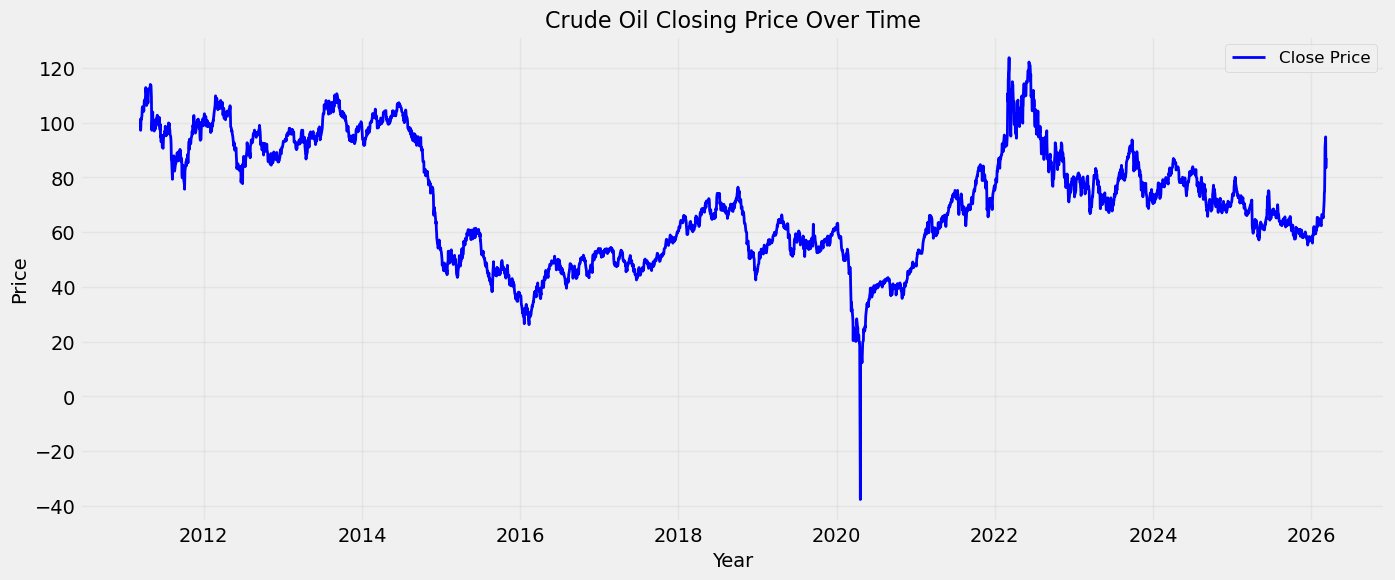

In [30]:
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='blue', linewidth=2)

plt.title("Crude Oil Closing Price Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [32]:
closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_24252\2942381381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_24252\2942381381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()


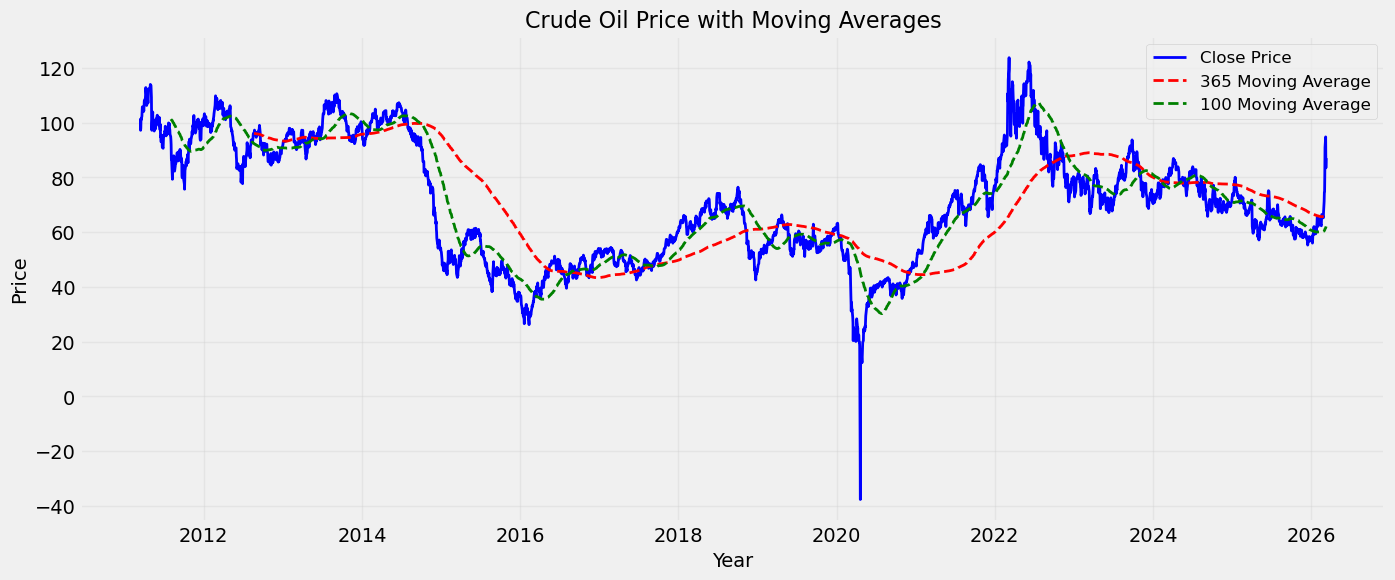

In [34]:
plt.figure(figsize=(15,6))

plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='blue', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_365'], label='365 Moving Average', color='red', linestyle="--", linewidth=2)
plt.plot(closing_price.index, closing_price['MA_100'], label='100 Moving Average', color='green', linestyle="--", linewidth=2)

plt.title("Crude Oil Price with Moving Averages", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [38]:
scaled_data

array([[0.86028641],
       [0.86047236],
       [0.83561646],
       ...,
       [0.82067811],
       [0.75051137],
       [0.77270192]])

In [40]:
len(scaled_data)

3772

In [42]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [43]:
x_data = []
y_data = []

base_days = 100

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])

x_data = np.array(x_data)
y_data = np.array(y_data)

In [44]:
train_size = int(len(x_data)*0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [48]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

C:\Users\Soham Rajapurkar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - loss: 0.0101
Epoch 2/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 5.7191e-04
Epoch 3/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/step - loss: 4.3357e-04
Epoch 4/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - loss: 3.7380e-04
Epoch 5/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - loss: 3.5351e-04
Epoch 6/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - loss: 3.1803e-04
Epoch 7/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - loss: 2.2387e-04
Epoch 8/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - loss: 2.4921e-04
Epoch 9/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 57s 86ms/step - loss: 2.2163e-04
Epoch 10/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - loss: 1.9561e-04


In [51]:
prediction = model.predict(x_test)

inv_predictions = scaler.inverse_transform(prediction)
inverse_y_test = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step


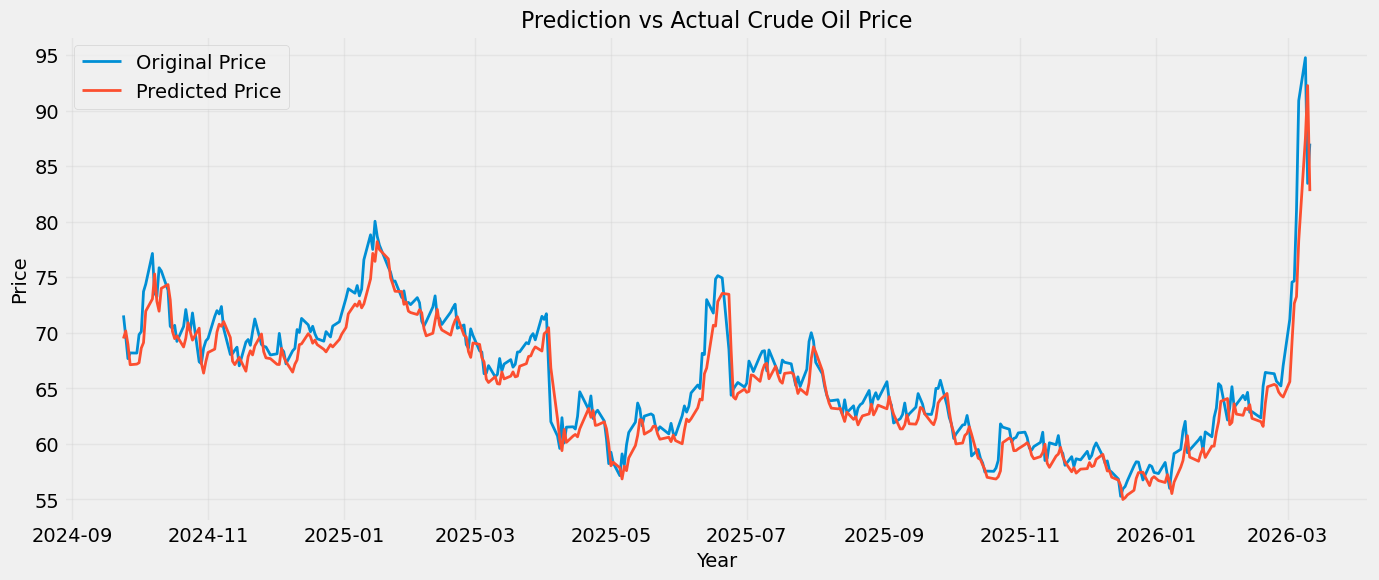

In [52]:
plotting_data = pd.DataFrame(
    {
        'Original': inverse_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    },
    index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize=(15,6))

plt.plot(plotting_data.index, plotting_data['Original'], label='Original Price', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label='Predicted Price', linewidth=2)

plt.title("Prediction vs Actual Crude Oil Price", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [53]:
last_100 = scaled_data[-100:].reshape(1,-1,1)

future_predictions = []

for _ in range(10):
    
    next_day = model.predict(last_100)
    
    future_predictions.append(scaler.inverse_transform(next_day))
    
    last_100 = np.append(last_100[:,1:,:], next_day.reshape(1,1,-1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [54]:
future_predictions = np.array(future_predictions).flatten()

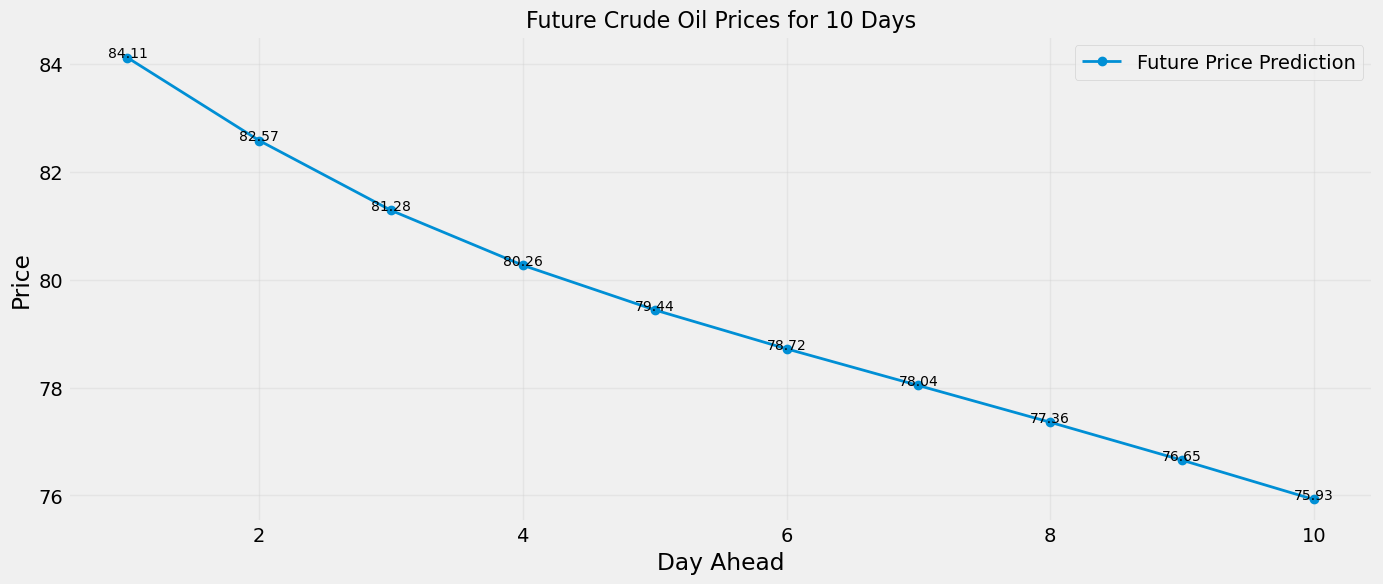

In [55]:
plt.figure(figsize=(15,6))

plt.plot(range(1,11), future_predictions, marker="o", label='Future Price Prediction', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center')

plt.title("Future Crude Oil Prices for 10 Days", fontsize=16)
plt.xlabel("Day Ahead")
plt.ylabel("Price")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [56]:
model.save("crude_oil_model.keras")

In [57]:
model.save("crude_oil_model.h5")